In [72]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE

DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]
SEED = 42

In [73]:
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
distance_matrix = np.load('../duomenys/dist_mat.npy')

In [74]:
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [75]:
from sklearn.model_selection import train_test_split

original_flat = original_data.reshape((-1, original_data.shape[1]*original_data.shape[2]))
X_train, X_test, y_train, y_test, emb_train, emb_test = train_test_split(
    original_flat, labels_encoded, embedding, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [76]:
import pandas as pd

In [77]:
from sklearn.metrics import confusion_matrix

In [78]:
def run_random_forest(X_train, X_test, y_train, y_test, label_names, **params):

    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    for param, v in params.items():
        print(f"{param} : {v}")
    print(f"{'='*60}")
    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm)
    print(cm_df.to_string())

    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)

    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n

    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in range(5)]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")

    return rf

In [79]:
rf_orig = run_random_forest(X_train, X_test, y_train, y_test, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  37   1   0   1   6
1   6  35   0   1   3
2   2   0  42   0   1
3   0   1   2  41   1
4   6   1   0   0  38

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.7255  0.8222  0.7708
Fishing       0.9211  0.7778  0.8434
Passenger     0.9545  0.9333  0.9438
Pilot         0.9535  0.9111  0.9318
Tanker        0.7755  0.8444  0.8085

Accuracy      : 0.8578
Macro precision : 0.8660
Macro recall    : 0.8578
Macro F1        : 0.8597


In [80]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    embedding, labels_encoded, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [81]:
rf_proj = run_random_forest(X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  25   5   4   1  10
1   6  34   0   0   5
2   2   0  37   3   3
3   0   0   2  40   3
4   8   3   3   0  31

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6098  0.5556  0.5814
Fishing       0.8095  0.7556  0.7816
Passenger     0.8043  0.8222  0.8132
Pilot         0.9091  0.8889  0.8989
Tanker        0.5962  0.6889  0.6392

Accuracy      : 0.7422
Macro precision : 0.7458
Macro recall    : 0.7422
Macro F1        : 0.7428


In [82]:
import matplotlib.colors as mcolors

In [83]:
def plot_decision_boundary(
    clf, 
    X_test_sc,
    y_test,
    label_names,
    title,
    ax,
    unique_classes,
    step=0.3
):

    x_min = X_test_sc[:,0].min() - 1
    x_max = X_test_sc[:,0].max() + 1
    y_min = X_test_sc[:,1].min() - 1
    y_max = X_test_sc[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_test == cls
        ax.scatter(X_test_sc[mask, 0], X_test_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")




In [84]:
import matplotlib.pyplot as plt

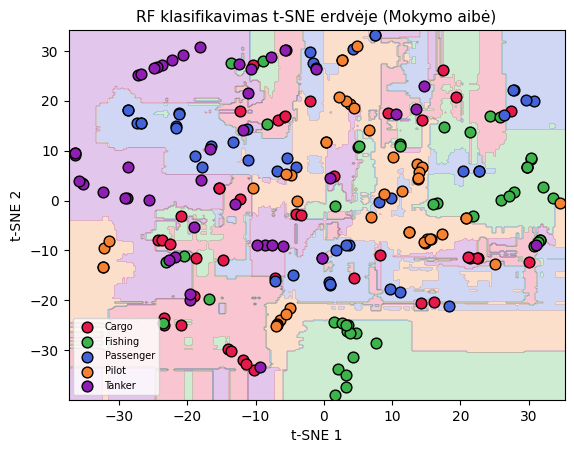

In [85]:
fig, ax = plt.subplots()

plot_decision_boundary(
    rf_proj, X_test_tsne, y_test_tsne, label_names, unique_classes=all_classes,
    title="RF klasifikavimas t-SNE erdvėje (Mokymo aibė)",
    ax=ax
)

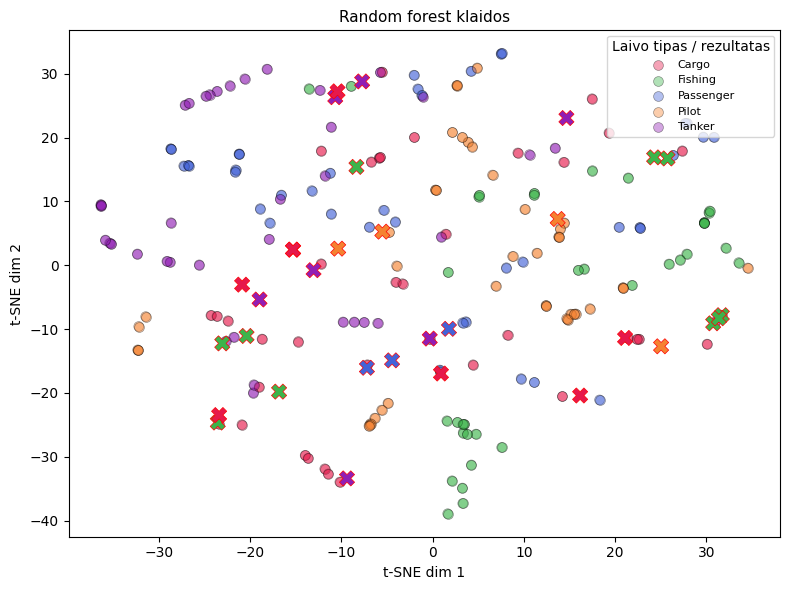

In [86]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_orig.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Random forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

param_grid = {
    'n_estimators': [20, 75, 100, 200],
    'max_depth':    [None, 8, 32, 64],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV acc:  {grid_search.best_score_:.4f}")

# Full results as a sorted DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_n_estimators', 'param_max_depth',
        'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

# ── Best model ready to use ───────────────────────────────────────────────────
rf_best = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params:  {'max_depth': None, 'n_estimators': 100}
Best CV acc:  0.8114
 param_n_estimators param_max_depth  mean_train_score  mean_test_score  std_test_score  rank_test_score
                100            None          1.000000         0.811429        0.044016                1
                100              32          1.000000         0.811429        0.044016                1
                100              64          1.000000         0.811429        0.044016                1
                 75            None          1.000000         0.809524        0.048562                4
                 75              32          1.000000         0.809524        0.048562                4
                 75              64          1.000000         0.809524        0.048562                4
                 20               8          0.924762         0.805714        0.051675                7
                200            

In [88]:
est = rf_orig.estimators_
depths = [estimator.tree_.max_depth for estimator in est]

max(depths)

23

> Geriausias hiperparametrų rinkinys - 75 estimatoriai ir neribotas medžio gylis (didžiausias gautas gylis - 24)

In [89]:
rf_optim = run_random_forest(X_train, X_test, y_train, y_test, label_names,
                            **grid_search.best_params_)


max_depth : None
n_estimators : 100
Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  37   3   0   1   4
1   5  36   0   1   3
2   2   0  43   0   0
3   1   0   2  41   1
4   6   2   0   1  36

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.7255  0.8222  0.7708
Fishing       0.8780  0.8000  0.8372
Passenger     0.9556  0.9556  0.9556
Pilot         0.9318  0.9111  0.9213
Tanker        0.8182  0.8000  0.8090

Accuracy      : 0.8578
Macro precision : 0.8618
Macro recall    : 0.8578
Macro F1        : 0.8588


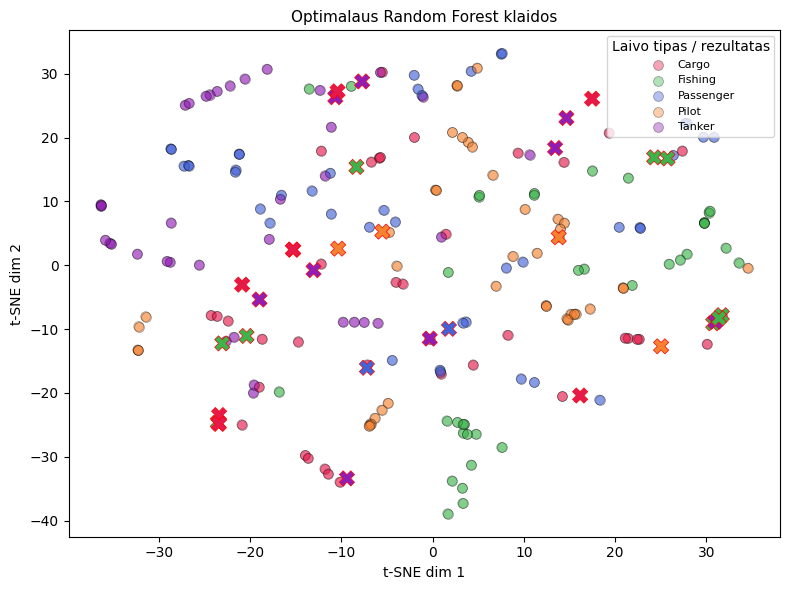

In [90]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Optimalaus Random Forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [91]:
unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

class_data = {
    'correct': {},
    'incorrect': {}
}

for cls in unique_cls:
    class_data['correct'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [correct & (y_test == cls)], axis=0
    ).mean(axis=0)

    class_data['incorrect'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [~correct & (y_test == cls)], axis=0
    ).mean(axis=0)

df = pd.DataFrame(
    {(status, label): values
     for status, classes in class_data.items()
     for label, values in classes.items()}
)

df['correct', 'feature_number'] = np.arange(df.shape[0])
df['incorrect', 'feature_number'] = np.arange(df.shape[0])

df_correct = df['correct'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_correct['status'] = 'correct'

df_incorrect = df['incorrect'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_incorrect['status'] = 'incorrect'

comparison_df = pd.concat([df_correct, df_incorrect], ignore_index=True)

In [92]:
pivot_df = comparison_df.pivot_table(
    index=['feature_number', 'class'],
    columns='status',
    values='mean_value'
).reset_index()

pivot_df.columns.name = None

pivot_df = pivot_df.rename(columns={
    'correct': 'mean_correct',
    'incorrect': 'mean_incorrect'
})

pivot_df['difference'] = pivot_df['mean_correct'] - pivot_df['mean_incorrect']
pivot_df['abs_difference'] = pivot_df['difference'].abs()

pivot_df = pivot_df.sort_values('abs_difference', ascending=False)

print(pivot_df.to_string(index=False))

 feature_number  class  mean_correct  mean_incorrect    difference  abs_difference
              7      2      0.468684        0.876297 -4.076131e-01    4.076131e-01
              1      4      0.684284        0.354027  3.302569e-01    3.302569e-01
              4      4      0.941913        0.615386  3.265279e-01    3.265279e-01
              3      3      0.114646        0.430635 -3.159892e-01    3.159892e-01
              3      2      0.455554        0.164557  2.909976e-01    2.909976e-01
              6      4      0.887033        0.609455  2.775786e-01    2.775786e-01
              3      1      0.125534        0.370302 -2.447681e-01    2.447681e-01
              5      2      0.487519        0.724382 -2.368631e-01    2.368631e-01
              8      1      0.012747        0.203293 -1.905461e-01    1.905461e-01
              1      2      0.362469        0.176401  1.860679e-01    1.860679e-01
              1      3      0.268299        0.085743  1.825568e-01    1.825568e-01
    

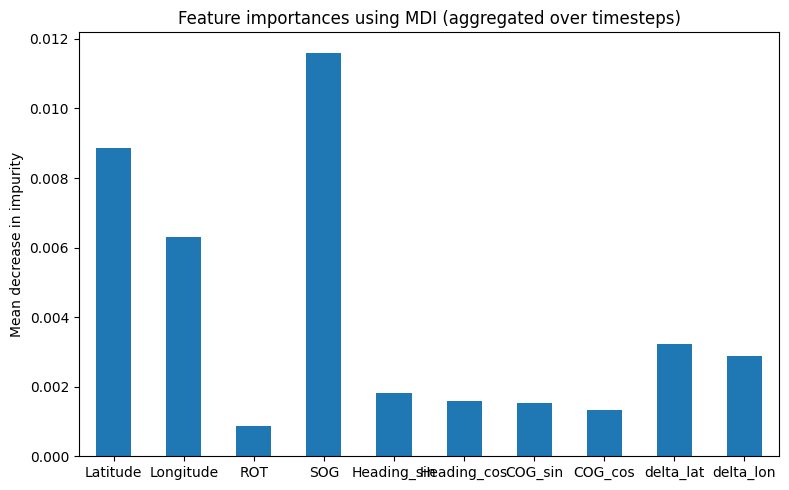

In [ ]:
n_timesteps = original_data.shape[1]  # 25
n_features  = original_data.shape[2]  # 10
feature_names_short = [
    'Latitude', 'Longitude', 'ROT',
    'SOG', 'Heading_sin', 'Heading_cos',
    'COG_sin', 'COG_cos', 'delta_lat', 'delta_lon'
]

# Reshape to (250,) -> (25, 10) and average over timesteps
imp_2d = rf_optim.feature_importances_.reshape(n_timesteps, n_features)
std_2d = np.std(
    [tree.feature_importances_.reshape(n_timesteps, n_features)
     for tree in rf_optim.estimators_], axis=0
)

importances_agg = imp_2d.mean(axis=0)   # shape (10,)
std_agg         = std_2d.mean(axis=0)   # shape (10,)

forest_importances = pd.Series(importances_agg, index=feature_names_short)

fig, ax = plt.subplots(figsize=(8, 5))
forest_importances.plot.bar(yerr=0, ax=ax)
ax.set_title("Požymių svarba pagal MDI") # (aggregated over timesteps)
ax.set_ylabel("MDI")
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

SOG and Latitude are clearly the most important features for distinguishing ship types.
Longitude is moderately important.
ROT, Heading, COG, delta_lat, delta_lon contribute relatively little.
The large error bars on SOG and Latitude mean their importance varies a lot depending on which timestep — which is exactly what the heatmap explains.

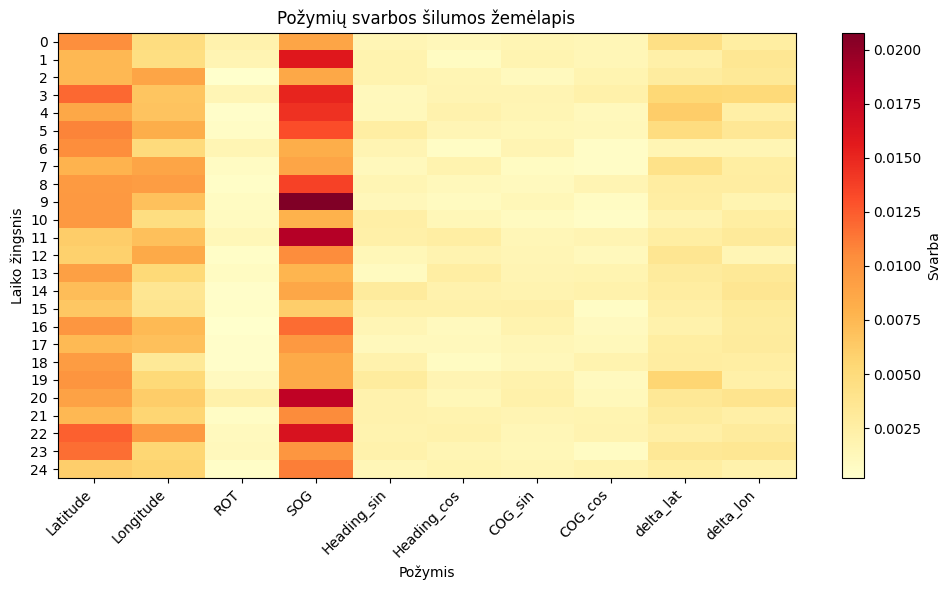

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(imp_2d, aspect='auto', cmap='YlOrRd')

ax.set_xlabel("Požymis")
ax.set_ylabel("Laiko žingsnis")
ax.set_title("Požymių svarbos tankio žemėlapis")

ax.set_xticks(range(n_features))
ax.set_xticklabels(feature_names_short, rotation=45, ha="right")

ax.set_yticks(range(n_timesteps))

plt.colorbar(im, ax=ax, label="Svarba")

fig.tight_layout()
plt.show()

SOG is the single most discriminative feature, and critically it matters most at timesteps 9–13 and 20–24 (the middle and end of the trajectory window), not at the most recent observation.
Latitude is consistently important across almost all timesteps — ships of different types tend to operate in different geographic zones
Longitude  matters most at earlier timesteps (0–8), then fades.
Everything else (ROT, Heading, COG, deltas) is largely uniform and pale — low importance throughout.

The practical takeaway: ship type is primarily encoded in how fast the ship is moving (SOG) and where it is geographically (Latitude), not in its heading or rate of turn.